## Kickstarter — Linguistic Patterns & Campaign Success

**Objective:** estimate the association between bigrams in campaign description text and campaign success, controlling for structural variables, with separate analysis per category.

### Structure
1. Setup & data loading  
2. Feature engineering  
3. Helper functions  
4. Intra-category model — bigram  

### Methodological note — model
Logistic regression is an interpretative tool, not a predictive one. The model estimates:

$$
P(\text{success}) = \sigma(\beta_0 + \beta_1 x_1 + \dots + \beta_k x_k)
$$

where $\sigma$ is the sigmoid function. The coefficients $\beta_j$ act on the log-odds:

$$
\log \left( \frac{P(\text{success})}{P(\text{failure})} \right)
= \beta_0 + \beta_1 x_1 + \dots + \beta_k x_k
$$

A positive coefficient on a bigram indicates an increase in the log-odds of success, holding all other controls constant. The effect on probability is non-linear and depends on the baseline level. This is not causal inference but a conditional association.

### Methodological note — AUC-ROC as a sanity check
The AUC-ROC (Area Under the Receiver Operating Characteristic Curve) measures the model’s ability to separate the two groups (success vs failure).

- AUC ≈ 0.5: no discrimination (equivalent to a coin flip)  
- AUC > 0.5: increasing separation  

In this notebook, AUC is not used to evaluate predictive power, but as a sanity check: if it were close to 0.5, the extracted coefficients would be unstable and not meaningful. Values clearly above 0.5 indicate that the regression captures a real signal.

The estimate is computed using 5-fold stratified cross-validation to avoid over-optimism.

### Methodological note — coefficient robustness
Bigrams are filtered by `doc_freq >= MIN_DF`. Coefficients on very rare terms are unstable even if large in magnitude: the filter reduces this issue by improving stability and interpretability, at the cost of excluding some rare signals.

## 1. Setup & data loading

In [4]:
import ast
import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.sparse import hstack

warnings.filterwarnings('ignore')

# ── Global parameters ──────────────────────────────────────────────────────────
MIN_DF_BIGRAM  = 20      # minimum document frequency threshold — bigram
BASELINE_CAT   = 'Film & Video'
CV_FOLDS       = 5
TOP_N          = 10      # bigrams shown in charts

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

In [ ]:
df = pd.read_csv('Kickstarter_processed.csv')
df['description_processed'] = df['description_processed'].apply(ast.literal_eval)

print(f'Shape: {df.shape}')
print(f'\nCategories:\n{df["category"].value_counts()}')
print(f'\nStatus (1=success, 0=failure):\n{df["status"].value_counts()}')

Shape: (6507, 15)

Categories:
category
Film & Video    1834
Technology      1358
Games           1115
Music           1112
Publishing      1088
Name: count, dtype: int64

Status (1=success, 0=failure):
status
1    4034
0    2473
Name: count, dtype: int64


## 2. Feature engineering

In [9]:
df['goal_log'] = np.log(df['goal'])
df['text_length'] = df['description_processed'].apply(len)
df['text_joined'] = df['description_processed'].apply(lambda x: ' '.join(x))

CONTROLS = ['goal_log', 'duration', 'text_length', 'video']
CATEGORIES = df['category'].unique().tolist()

print('Numeric controls:', CONTROLS)
print('Categories:', CATEGORIES)

df[CONTROLS + ['status']].describe().round(3)

Numeric controls: ['goal_log', 'duration', 'text_length', 'video']
Categories: ['Film & Video', 'Games', 'Music', 'Publishing', 'Technology']


,goal_log,duration,text_length,video,status
count,6507.000,6507.000,6507.000,6507.000,6507.000
mean,9.681,34.465,436.815,0.882,0.620
std,0.814,11.289,347.829,0.323,0.485
min,8.517,3.000,32.000,0.000,0.000
25%,9.105,30.000,192.500,1.000,0.000
50%,9.473,30.000,337.000,1.000,1.000
75%,10.127,37.500,574.000,1.000,1.000
max,13.816,91.000,2895.000,1.000,1.000


In this section, we construct the variables used in the linguistic model. The main textual feature is the campaign description length, while the structural controls include the funding goal, campaign duration, and the presence of a video.

The funding goal is log-transformed to reduce the influence of extreme values and make the scale more suitable for regression. The variable text_length measures the number of processed tokens in each campaign description and is included as a control, so that bigram coefficients do not simply capture the effect of longer texts. The variable text_joined converts the processed tokens back into a single string, which is required for bigram extraction.

The summary statistics are used as a quick consistency check. Campaigns have a median duration of 30 days and a median description length of 337 tokens. The variable video is binary, so its mean can be interpreted as a proportion: about 88.2% of campaigns include a video, and 62% of the observations are successful. These controls are then used in the category-specific logistic regressions together with the linguistic features.

## 3. Helper functions

In [4]:
def make_model():
    """L2-regularised logistic regression with balanced class weights."""
    return LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        max_iter=500,
        class_weight='balanced'
    )


def evaluate_auc(X, y):
    """
    AUC-ROC in 5-fold stratified CV.
    Sanity check: verifies that the model discriminates between success and
    failure better than chance (AUC >> 0.5). Not a predictive evaluation.
    """
    cv     = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
    scores = cross_val_score(make_model(), X, y, cv=cv, scoring='roc_auc')
    return pd.DataFrame({
        'AUC-ROC mean': [round(scores.mean(), 3)],
        'AUC-ROC std':  [round(scores.std(),  3)]
    })


def extract_coefs(model, feature_names, X_text, min_doc_freq, col_name='bigram'):
    """Extract token coefficients with doc_freq filter."""
    coef     = model.coef_[0][:len(feature_names)]
    doc_freq = np.asarray((X_text > 0).sum(axis=0)).flatten()
    info = pd.DataFrame({
        col_name:   feature_names,
        'coef':     coef.round(4),
        'doc_freq': doc_freq
    })
    return info[info['doc_freq'] >= min_doc_freq].copy().reset_index(drop=True)


def show_top(info, col_name, n=TOP_N):
    """Print top n tokens associated with success and failure."""
    cols = [col_name, 'coef', 'doc_freq']
    print(f'\n--- TOP {n} associated with SUCCESS ---')
    display(info.sort_values('coef', ascending=False).head(n)[cols].reset_index(drop=True))
    print(f'\n--- TOP {n} associated with FAILURE ---')
    display(info.sort_values('coef').head(n)[cols].reset_index(drop=True))


def plot_coefs(info, col_name, cat_name, n=TOP_N):
    """
    Horizontal bar chart of the top/bottom n bigrams by coefficient.
    Coefficients are on the log-odds scale: positive = associated with success,
    negative = associated with failure.
    """
    top_success = info.sort_values('coef', ascending=False).head(n)
    top_failure = info.sort_values('coef').head(n)
    combined    = pd.concat([top_success, top_failure]).drop_duplicates(subset=col_name)
    combined    = combined.sort_values('coef')

    colors = ['#d62728' if c < 0 else '#2ca02c' for c in combined['coef']]

    fig, ax = plt.subplots(figsize=(9, max(5, len(combined) * 0.38)))
    bars = ax.barh(combined[col_name], combined['coef'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient (log-odds)', fontsize=11)
    ax.set_title(f'{cat_name} — Bigrams most associated with success (green) and failure (red)',
                 fontsize=12, fontweight='bold', pad=12)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # value annotations
    for bar, val in zip(bars, combined['coef']):
        offset = 0.005 * (combined['coef'].max() - combined['coef'].min())
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + (offset if val >= 0 else -offset),
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha=ha, fontsize=8.5)

    plt.tight_layout()
    plt.show()


def run_intracat_bigram(df, cat, min_df=MIN_DF_BIGRAM):
    """Fit bigram logistic regression on a category subset + AUC-ROC + coefficient extraction."""
    df_cat = df[df['category'] == cat].copy().reset_index(drop=True)
    y_cat  = df_cat['status'].values

    vec    = CountVectorizer(ngram_range=(2, 2), min_df=min_df)
    X_text = vec.fit_transform(df_cat['text_joined'])
    feat   = vec.get_feature_names_out()

    scaler = StandardScaler()
    X_num  = sp.csr_matrix(scaler.fit_transform(df_cat[CONTROLS]))
    X      = hstack([X_text, X_num])

    model  = make_model()
    model.fit(X, y_cat)

    auc_df = evaluate_auc(X, y_cat)
    info   = extract_coefs(model, feat, X_text, min_doc_freq=min_df, col_name='bigram')

    return info, auc_df

## 4. Intra-category model — bigram

Specification per category: `P(success) ~ bag-of-words representation of bigrams + goal_log + duration + text_length + video`

No category dummies (the model already runs on a homogeneous subset).

For each category the following are reported:
- AUC-ROC (5-fold stratified CV): sanity check on the model's discriminative quality
- Top bigrams associated with success: positive log-odds coefficients
- Top bigrams associated with failure: negative log-odds coefficients
- Chart: horizontal bars for immediate reading of coefficients

How to read the coefficients: A coefficient of +0.30 on a bigram indicates that its presence is associated with an increase of 0.30 in the log-odds of success, holding other variables constant. The mapping to probability is non-linear and depends on the baseline level of the probability.


  Film & Video — bigram

--- AUC-ROC (5-fold stratified CV) ---


,AUC-ROC mean,AUC-ROC std
0,0.717,0.012


→ AUC = 0.717 ± 0.012: good discriminative ability — coefficients are reliable

--- TOP 10 associated with SUCCESS ---


,bigram,coef,doc_freq
0,credit card,2.0236,47
1,follow twitter,1.6937,38
2,theme song,1.5378,20
3,finish post,1.4032,23
4,believe film,1.3431,31
5,woman film,1.2682,22
6,director statement,1.2618,62
7,dear friend,1.2402,20
8,film place,1.2281,44
9,watch video,1.2231,41



--- TOP 10 associated with FAILURE ---


,bigram,coef,doc_freq
0,film adaptation,-1.4200,20
1,large scale,-1.4007,36
2,light camera,-1.3859,21
3,win writer,-1.2456,26
4,dream big,-1.1914,21
5,film shoot,-1.1836,31
6,film premier,-1.1782,20
7,film live,-1.1117,33
8,film call,-1.0938,39
9,ensure film,-1.0919,24


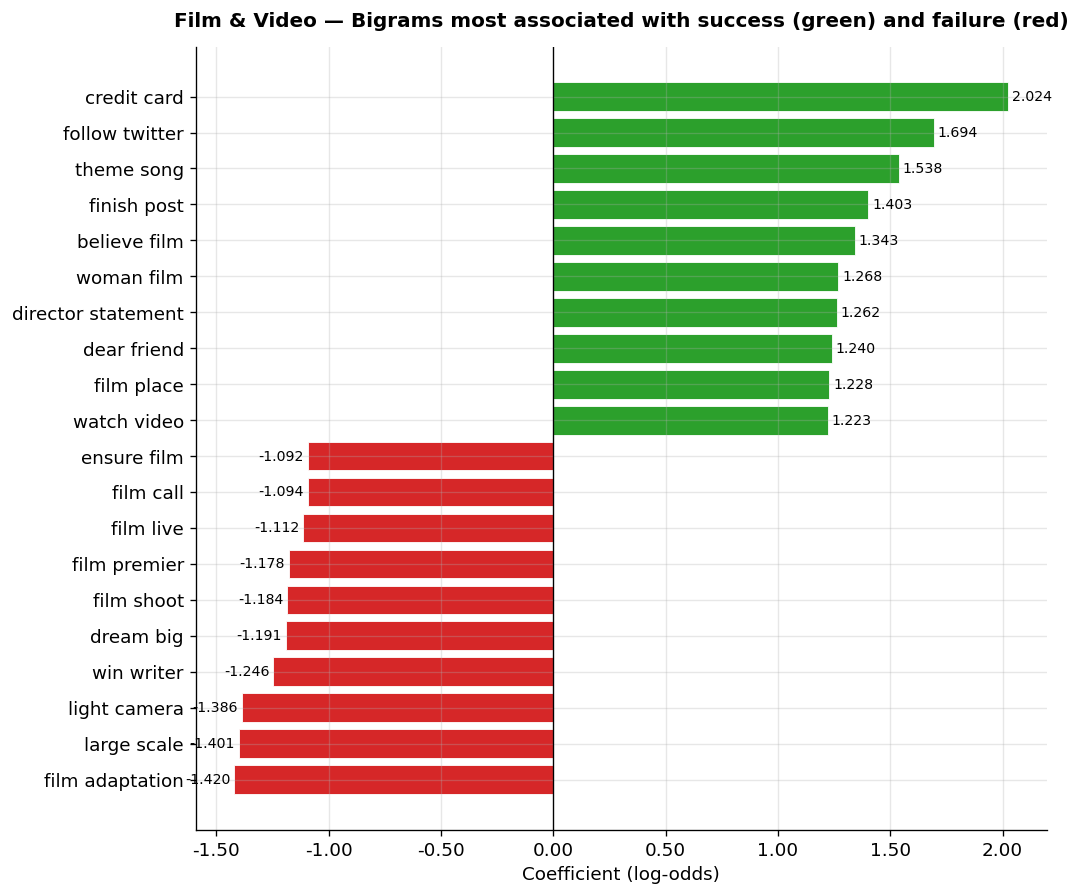


  Games — bigram

--- AUC-ROC (5-fold stratified CV) ---


,AUC-ROC mean,AUC-ROC std
0,0.742,0.021


→ AUC = 0.742 ± 0.021: good discriminative ability — coefficients are reliable

--- TOP 10 associated with SUCCESS ---


,bigram,coef,doc_freq
0,ship fee,1.3199,26
1,press kit,1.2317,23
2,choice shape,1.2250,20
3,sticker sheet,1.2213,20
4,stretch unlock,1.1544,45
5,expand game,1.1384,27
6,ship backer,1.1009,25
7,pledge tier,1.0891,72
8,reward add,1.0813,34
9,add pledge,1.0806,40



--- TOP 10 associated with FAILURE ---


,bigram,coef,doc_freq
0,early supporter,-1.6724,22
1,build something,-1.4368,32
2,role game,-1.2465,43
3,win game,-1.2109,51
4,may vary,-1.1947,29
5,uncover secret,-1.1374,20
6,choose reward,-1.1122,22
7,free game,-1.0398,23
8,come soon,-1.0385,25
9,development game,-1.0311,32


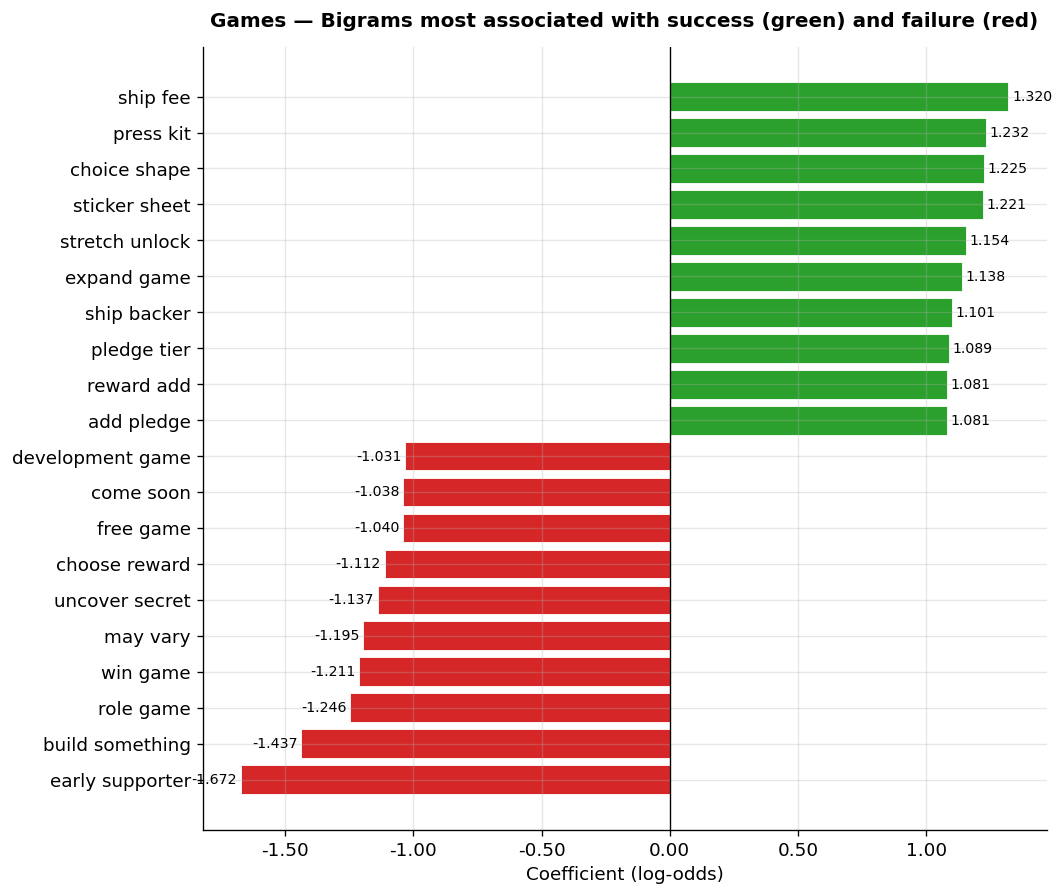


  Music — bigram

--- AUC-ROC (5-fold stratified CV) ---


,AUC-ROC mean,AUC-ROC std
0,0.674,0.037


→ AUC = 0.674 ± 0.037: moderate discriminative ability — interpret with caution

--- TOP 10 associated with SUCCESS ---


,bigram,coef,doc_freq
0,friend fan,1.8268,46
1,song ep,1.5862,33
2,chamber music,1.5156,20
3,reward list,1.5015,21
4,graphic designer,1.4768,25
5,co write,1.4657,30
6,please consider,1.3545,34
7,rock band,1.3277,31
8,produce record,1.2452,29
9,musician album,1.2423,22



--- TOP 10 associated with FAILURE ---


,bigram,coef,doc_freq
0,marketing promotion,-1.5152,23
1,money record,-1.4353,22
2,video song,-1.2424,23
3,thank advance,-1.0757,30
4,music song,-1.0694,25
5,dream true,-1.0297,28
6,track record,-0.9634,27
7,produce music,-0.9566,29
8,music scene,-0.8493,35
9,card charge,-0.8094,27


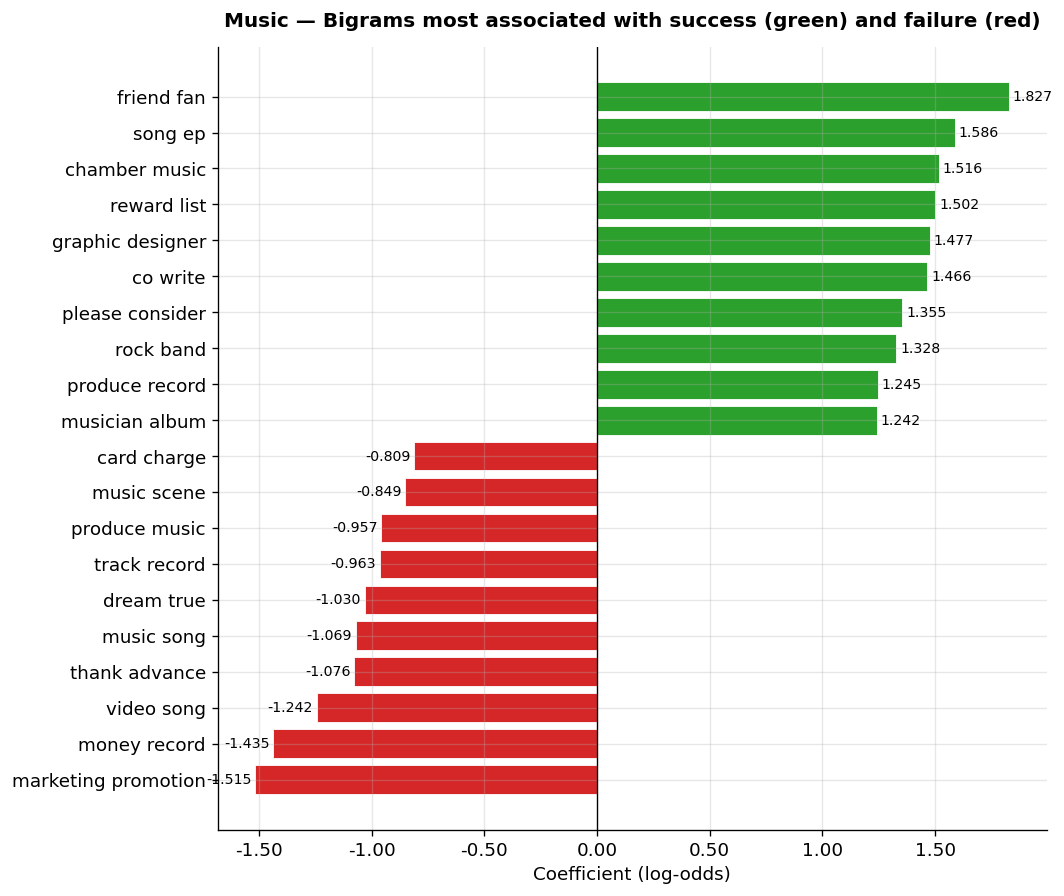


  Publishing — bigram

--- AUC-ROC (5-fold stratified CV) ---


,AUC-ROC mean,AUC-ROC std
0,0.727,0.031


→ AUC = 0.727 ± 0.031: good discriminative ability — coefficients are reliable

--- TOP 10 associated with SUCCESS ---


,bigram,coef,doc_freq
0,print book,1.5084,90
1,special thanks,1.4832,33
2,printing cost,1.4498,34
3,book art,1.3663,24
4,book special,1.3088,28
5,donate book,1.2892,29
6,original art,1.2715,20
7,book hope,1.2631,20
8,author illustrator,1.1953,37
9,book base,1.1857,23



--- TOP 10 associated with FAILURE ---


,bigram,coef,doc_freq
0,ons add,-1.2728,20
1,final product,-1.1988,21
2,ship cost,-1.0783,34
3,book sign,-1.0033,45
4,reward backer,-0.9566,32
5,build community,-0.9518,24
6,think provoke,-0.9219,20
7,tax fee,-0.8821,22
8,complete book,-0.8401,25
9,perfect bound,-0.8398,21


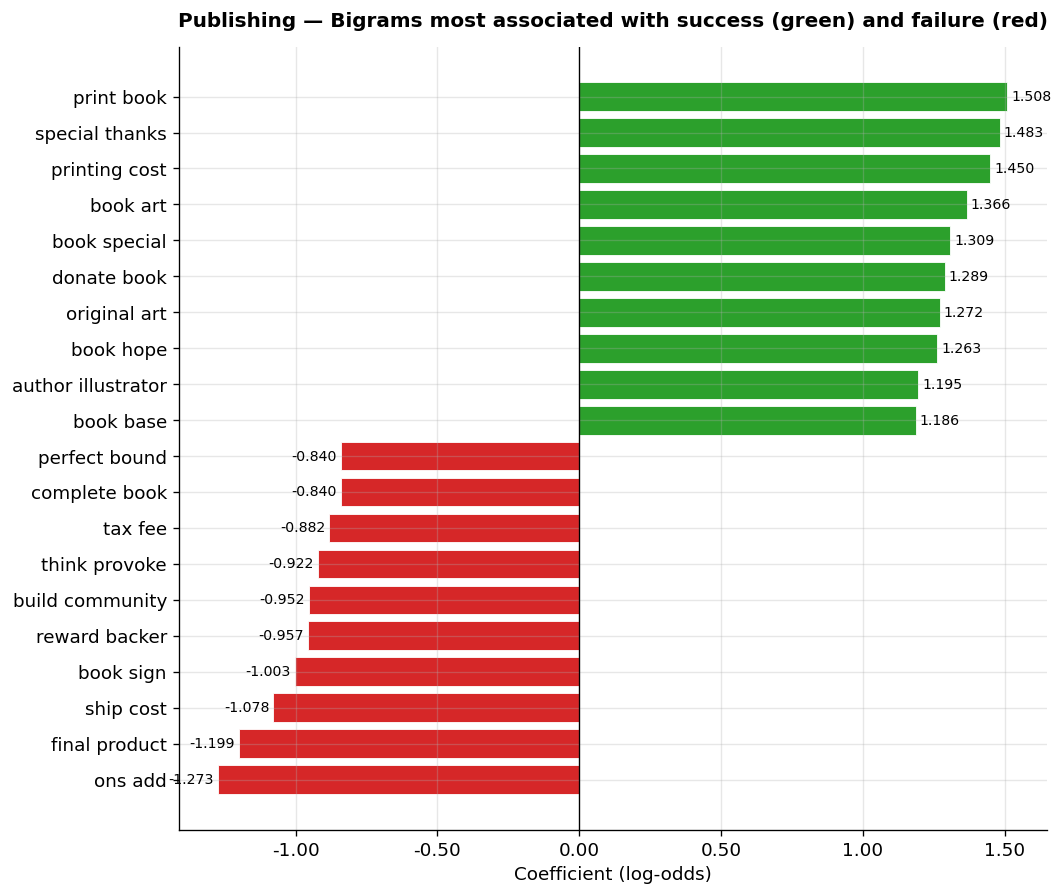


  Technology — bigram

--- AUC-ROC (5-fold stratified CV) ---


,AUC-ROC mean,AUC-ROC std
0,0.707,0.026


→ AUC = 0.707 ± 0.026: good discriminative ability — coefficients are reliable

--- TOP 10 associated with SUCCESS ---


,bigram,coef,doc_freq
0,product designer,1.8034,22
1,color option,1.7749,31
2,add ons,1.4405,85
3,super easy,1.2766,20
4,small size,1.2157,23
5,promote jellop,1.1564,79
6,reward tier,1.1252,40
7,polymer battery,1.1205,20
8,innovative product,1.1086,29
9,management system,1.0106,22



--- TOP 10 associated with FAILURE ---


,bigram,coef,doc_freq
0,price point,-1.4937,26
1,together build,-1.4825,23
2,video show,-1.2742,35
3,idea come,-1.2211,22
4,feel good,-1.2009,20
5,software engineer,-1.1236,25
6,smart phone,-1.0753,39
7,smart device,-1.0424,45
8,state art,-0.9564,53
9,early access,-0.9553,38


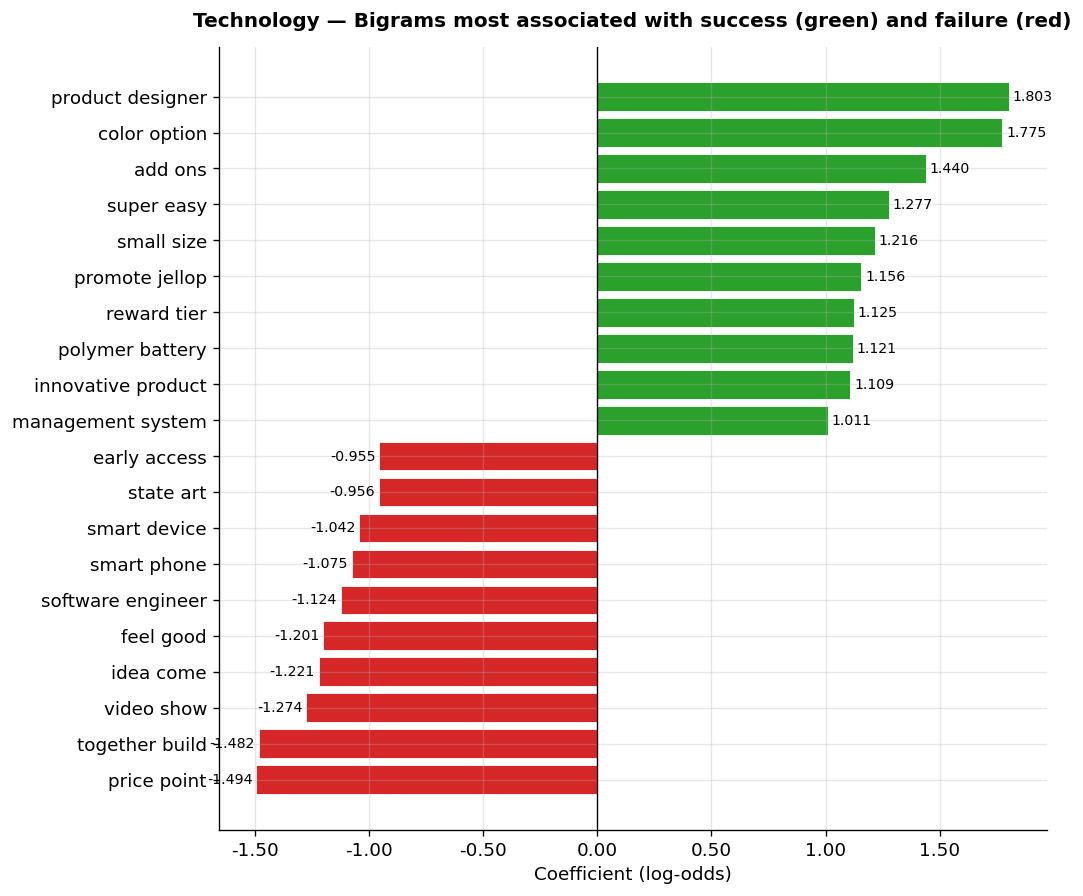

In [5]:
for cat in CATEGORIES:
    print(f'\n{"="*50}')
    print(f'  {cat} — bigram')
    print(f'{"="*50}')

    info, auc_df = run_intracat_bigram(df, cat)

    # ── AUC ──────────────────────────────────────────────────────────────────
    print('\n--- AUC-ROC (5-fold stratified CV) ---')
    auc_mean = auc_df['AUC-ROC mean'].values[0]
    auc_std  = auc_df['AUC-ROC std'].values[0]
    display(auc_df)
    if auc_mean >= 0.70:
        label = 'good discriminative ability — coefficients are reliable'
    elif auc_mean >= 0.60:
        label = 'moderate discriminative ability — interpret with caution'
    else:
        label = 'weak discriminative ability — coefficients should be taken with caution'
    print(f'→ AUC = {auc_mean:.3f} ± {auc_std:.3f}: {label}')

    # ── Coefficient tables ───────────────────────────────────────────────────
    show_top(info, col_name='bigram')

    # ── Chart ─────────────────────────────────────────────────────────────────
    plot_coefs(info, col_name='bigram', cat_name=cat)

## 5. Reading the results — interpretation guide

### AUC-ROC: what it tells us

AUC-ROC measures how well the model separates successful from failed campaigns within each category. In this analysis, it is used as a sanity check rather than as evidence of strong predictive performance.

| Range | Interpretation |
|---|---|
| Around 0.50 | Little or no separation between successful and failed campaigns |
| 0.55–0.65 | Weak but non-random signal |
| 0.65–0.75 | Moderate separation; coefficients can be inspected with caution |
| Above 0.75 | Stronger separation, though still not causal evidence |

Across categories, AUC values range from 0.674 to 0.742. This suggests that the combination of bigram features and structural controls captures some systematic differences between successful and failed campaigns. However, these values should not be interpreted as high predictive accuracy. They indicate that the model contains useful signal, not that campaign success can be reliably predicted from description text alone.

### Logistic regression coefficients: what they mean

The model estimates:

$$
\log \left( \frac{P(\text{success})}{1-P(\text{success})} \right)
=
\beta_0 + \sum_j \beta_j \cdot \mathbf{1}\{\text{bigram}_j \in \text{text}\} + \gamma^\top z
$$

where \(z\) contains the structural controls: goal, duration, text length, and video.

A positive coefficient means that the presence of a bigram is associated with higher log-odds of success, holding the controls constant. A negative coefficient means that the bigram is associated with lower log-odds of success. These coefficients should be interpreted as conditional associations, not causal effects.

The size of a coefficient is comparable across bigrams within the same category, but it should not be read as a direct probability change. The translation from log-odds to probability depends on the baseline probability of success.

### Patterns to inspect

The bigrams with positive coefficients often contain category-specific or product-specific language. These terms may indicate more concrete descriptions, clearer project framing, or vocabulary that is typical of successful campaigns in that category.

The bigrams with negative coefficients often include more generic, vague, procedural, or weakly differentiated expressions. However, this should be interpreted cautiously: a negative coefficient does not prove that the phrase itself causes failure. It only indicates that the phrase appears more often in campaigns that failed, after controlling for the included variables.

### Caveats

The results are observational and should not be interpreted causally. The model does not identify whether specific phrases increase success, nor does it measure project quality, creator experience, audience size, platform visibility, or external promotion.

The estimates also depend on preprocessing choices, document-frequency thresholds, and the selected controls. Rare bigrams are filtered to improve stability, but some potentially informative terms may be excluded.


## Conclusions

The bigram-based logistic models identify systematic associations between textual features and campaign success across categories. The AUC-ROC values range from 0.674 to 0.742, indicating that the combination of linguistic features and structural controls captures a moderate signal beyond random separation. These values support the presence of informative patterns in campaign descriptions, but do not imply strong predictive performance.

The strength of the signal varies across categories. Games shows the highest AUC (0.742 ± 0.021), suggesting clearer separation between successful and failed campaigns, while Music shows the lowest (0.674 ± 0.037), indicating greater heterogeneity or noise. Film & Video, Publishing, and Technology fall in between, with relatively stable but moderate discrimination.

The associations should be interpreted cautiously. The coefficients reflect correlations in the data rather than causal effects, and the presence of a given bigram may be correlated with unobserved factors such as project quality, creator experience, or external promotion.

The results therefore suggest that campaign descriptions contain category-specific linguistic signals related to success, but they do not establish that particular wording strategies directly influence outcomes. Instead, the identified patterns should be understood as descriptive indicators of differences between successful and failed campaigns.

Overall, the analysis provides evidence that textual features carry measurable information about campaign outcomes, while highlighting the limits of purely observational and feature-based approaches in explaining success.